# Agricultural Price Data — Model Selection, feature engineering, model Training-Comparision-Finalise
---
**Dataset:** Monthly Average Price Data &nbsp;|&nbsp; **Columns:** `date`, `avg_monthly_price`

This notebook walks through the full theoretically selecting the correct models and training them and comparing between them.

## 0. Import Libraries

In [66]:
import pandas as pd
import numpy as np
import pickle

# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Regressor Models
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

np.random.seed(42)

---
## 1. Model Selection

I evaluated several model families against the specific characteristics of this dataset — long history (249 months), clear seasonality, non-stationarity, and a recent structural break.

**Model Comparison**

| Model | Handles Seasonality | Custom Features | Captures Recent Trends | Recency Weighting | Complexity |
|---|---|---|---|---|---|
| ARIMA | ❌ | ❌ | ⚠️ | ❌ | Low |
| SARIMA | ✅ | ❌ | ⚠️ | ❌ | Medium |
| Prophet | ✅ | ⚠️ | ⚠️ | ❌ | Low |
| LSTM | ✅ | ❌ | ✅ | ⚠️ | High |
| Random Forest | ❌ | ✅ | ✅ | ⚠️ | Medium |
| XGBoost | ❌ (manual) | ✅ | ✅ | ✅ | Medium |
| **Hybrid SARIMA + GBM/XGB** | ✅ | ✅ | ✅ | ✅ | High |

The key constraint is the recent structural break — pure SARIMA will underfit the post-2020 regime because it weights all history equally. The hybrid approach uses SARIMA to model the seasonal and trend structure, then trains a gradient boosting model on the *residuals* to capture whatever pattern SARIMA missed. This is a well-established technique for handling non-linearities that ARIMA-family models can't represent.

**Decision: SARIMA + XGBoost and SARIMA + GBM (both trained and compared)**

Both hybrid variants are trained so I can compare which boosting approach does a better job on the residuals. The final 12-month forecast uses whichever performs better on the test split.

---
## 2. Feature Engineering & Transformations

Several transforms and features are needed before the boosting models can work well on the residuals:

**Log transform (`np.log1p`):** Stabilises variance and compresses the right tail introduced by the post-2020 price spikes. Predictions are back-transformed with `np.expm1` at the end.

**Lag features (1, 2, 3, 12):** Give the model direct access to recent price history. Lag 12 is especially important — it's the same month last year, which is the single strongest predictor for seasonal series.

**Rolling mean and std (3-month):** Encode short-term momentum and local volatility into each row, so the model doesn't have to infer them from individual lags alone.

**Seasonal encoding (sin/cos of month):** Converts the month integer into circular features — ensures the model understands that December and January are adjacent, not 11 months apart.

**Recency weighting:** Sample weights that increase exponentially for more recent observations. This makes the boosting models prioritise fitting the post-2020 regime without discarding earlier data entirely.

Note: the `avg_monthly_price` column is renamed to `price` after the log transform, and all EDA columns (rolling means, outlier flags etc.) are dropped to keep the feature set clean.

In [73]:
final_path = "price_data.csv"

df = pd.read_csv(final_path, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Set index
df.set_index('date', inplace=True)

# Ensure monthly frequency
df = df.asfreq('MS')

# Rename target column
#df['price'] = df['price_diff']
df['price']=df['avg_monthly_price']

# =========================
# 2. LOG TRANSFORM
# =========================

df['price'] = np.log1p(df['price'])

# =========================
# 3. LAG FEATURES
# =========================

df['lag_1'] = df['price'].shift(1)
df['lag_2'] = df['price'].shift(2)
df['lag_3'] = df['price'].shift(3)
df['lag_12'] = df['price'].shift(12)

# =========================
# 4. ROLLING FEATURES
# =========================

df['rolling_mean_3'] = df['price'].shift(1).rolling(3).mean()
df['rolling_std_3'] = df['price'].shift(1).rolling(3).std()

# =========================
# 5. TREND FEATURES
# =========================

df['diff_1'] = df['price'].diff(1)

# =========================
# 6. SEASONAL FEATURES
# =========================

df['month'] = df.index.month

df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# =========================
# 7. YEARLY CONTEXT
# =========================

df['avg_price_last_year'] = df['price'].shift(1).rolling(12).mean()

# =========================
# 8. RECENCY WEIGHT
# =========================

current_year = df.index.year.max()
df['weight'] = np.exp(-0.3 * (current_year - df.index.year))

# =========================
# 9. DROP UNUSED COLUMNS
# =========================

drop_cols = [
    'avg_monthly_price', 'month_name', 'quarter', 'season',
    'iqr_outlier', 'zscore', 'zscore_outlier',
    'roll_3', 'roll_6', 'roll_12', 'ewm_24',
    'price_diff', 'pct_change',
    'rolling_std3', 'rolling_std6'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

---
## 3. SARIMA Model Training and Evaluation

The SARIMA search is done with a manual grid rather than `auto_arima` — mainly for transparency and to keep the search space tight based on what the ACF/PACF already suggested.

The two arrays `a` and `A` define the non-seasonal (p,d,q) and seasonal (P,D,Q) order combinations to try. Each row is one combination. The nested loop fits every combination of non-seasonal × seasonal orders and keeps whichever produces the lowest AIC. Models that fail to converge are skipped silently.

In [76]:
from itertools import product

# Define ranges
p = range(0, 4)   # 0–3
d = range(0, 3)   # 0–2
q = range(0, 4)   # 0–3

P = range(0, 3)   # 0–2
D = range(0, 2)   # 0–1
Q = range(0, 3)   # 0–2

# Generate combinations
a = np.array(list(product(p, d, q)))   # (p,d,q)
A = np.array(list(product(P, D, Q)))   # (P,D,Q)

# Check
print("a shape:", a.shape)
print("A shape:", A.shape)
print(a[:5])  # first few combinations
print(A[:5])

a shape: (48, 3)
A shape: (18, 3)
[[0 0 0]
 [0 0 1]
 [0 0 2]
 [0 0 3]
 [0 1 0]]
[[0 0 0]
 [0 0 1]
 [0 0 2]
 [0 1 0]
 [0 1 1]]


In [78]:
# Initialize trackers
best_aic = float('inf')
best_order = None
best_seasonal_order = None
best_model = None

# Loop over all combinations
for i in range(len(a)):
    for j in range(len(A)):
        p, d, q = a[i]
        P, D, Q = A[j]

        try:
            model = SARIMAX(
                df['price'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, 12),  # monthly seasonality
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            # Check if this model is better
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, d, q)
                best_seasonal_order = (P, D, Q, 12)
                best_model = model

        except Exception as e:
            print(f"Failed for order {(p,d,q)} seasonal {(P,D,Q,12)}: {e}")
            continue

# Assign best model
best_sarimax = best_model

# Print results
print("Best SARIMAX model:")
print(f"Order (p,d,q): {best_order}")
print(f"Seasonal order (P,D,Q,s): {best_seasonal_order}")
print(f"AIC: {best_aic}")

C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\

Best SARIMAX model:
Order (p,d,q): (np.int64(2), np.int64(1), np.int64(3))
Seasonal order (P,D,Q,s): (np.int64(0), np.int64(0), np.int64(1), 12)
AIC: -454.9933615760975


C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [79]:
# =========================
# ✅ Save the model (recommended way)
# =========================
best_sarimax.save("best_sarimax_model.pkl")

# =========================
# ✅ Optional: Save using pickle (backup)
# =========================
with open("best_sarimax_pickle.pkl", "wb") as f:
    pickle.dump(best_sarimax, f)

# =========================
# ✅ Save metadata
# =========================
model_info = {
    "order": best_order,
    "seasonal_order": best_seasonal_order,
    "aic": best_aic
}

with open("sarimax_metadata.pkl", "wb") as f:
    pickle.dump(model_info, f)

In [82]:
# 1. Get residuals to feed to XGBoost / LightGBM
residuals = best_sarimax.resid.dropna()

# 2. Prepare features for boosting (e.g., lag features)
df_ml = pd.DataFrame({
    'residual': residuals
})
for lag in range(1, 13):
    df_ml[f'lag_{lag}'] = df_ml['residual'].shift(lag)

df_ml['rolling_mean_3'] = df_ml['residual'].rolling(3).mean()
df_ml['rolling_std_3'] = df_ml['residual'].rolling(3).std()

df_ml = df_ml.dropna()

<Axes: title={'center': 'SARIMA Residuals'}, xlabel='date'>

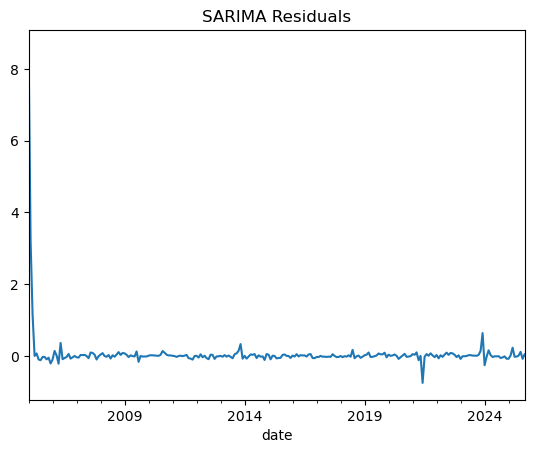

In [84]:
residuals.plot(title="SARIMA Residuals")

The residual plot should look like noise — no obvious trend, no seasonal humps, and the values centred around zero. If there's still structure visible here, it means SARIMA didn't fully capture the series and the boosting model will need to work harder. Residuals drifting away from zero in recent periods would be a red flag.

---
## 4. GBM and XGBoost — Residual Model Training

80/20 train/test split on the residual series. Since this is a time series, the split is sequential — the last 20% of residuals form the test set, not a random sample. Random splitting would leak future information into training and give artificially good metrics.

The `recency_weight` array logarithmically scales across the training set. Combined with the `error_weight` (proportional to the magnitude of each residual), the final `weights` vector forces the model to focus on recent, large errors — exactly where we want it to be accurate for near-term forecasting.

In [89]:
train_size = int(len(df_ml) * 0.8)

train = df_ml[:train_size]
test = df_ml[train_size:]

X_train = train.drop('residual', axis=1)
y_train = train['residual']

X_test = test.drop('residual', axis=1)
y_test = test['residual']

indices = np.arange(1, len(y_train)+1)
recency_weight = np.log(indices + 1)
error_weight = np.abs(y_train)

weights = recency_weight * (1 + error_weight)

Grid search over learning rates (0.01 to 0.09 in steps of 0.01) and max depths (1 to 9). 81 combinations × 2 models = 162 model fits. The results are collected into a dataframe and sorted by RMSE so the best hyperparameters are at the top.

Both XGBoost and GBM are searched together so we can compare them on equal footing before committing to one.

In [92]:
# Evaluation function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

# Track best model
best_rmse = float("inf")
best_residual_model = None
best_model_name = None
best_params = {}

# Loop
for i in range(1, 10):
    for j in range(1, 10):
        lr = 0.01 * i

        # XGBoost
        xgb_model = XGBRegressor(
            n_estimators=500,
            learning_rate=lr,
            max_depth=j
        )
        xgb_model.fit(X_train, y_train, sample_weight=weights)
        xgb_pred = xgb_model.predict(X_test)
        xgb_rmse = evaluate_model(y_test, xgb_pred)

        if xgb_rmse < best_rmse:
            best_rmse = xgb_rmse
            best_residual_model = xgb_model
            best_model_name = "XGBoost"
            best_params = {"learning_rate": lr, "max_depth": j}

        # Gradient Boosting
        gbm_model = GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=lr,
            max_depth=j,
            random_state=42
        )
        gbm_model.fit(X_train, y_train, sample_weight=weights)
        gbm_pred = gbm_model.predict(X_test)
        gbm_rmse = evaluate_model(y_test, gbm_pred)

        if gbm_rmse < best_rmse:
            best_rmse = gbm_rmse
            best_residual_model = gbm_model
            best_model_name = "Gradient Boosting"
            best_params = {"learning_rate": lr, "max_depth": j}


# ✅ Print best model info
print("\n🏆 Best Residual Model:")
print("Model:", best_model_name)
print("Best RMSE:", round(best_rmse, 3))
print("Best Parameters:", best_params)


# =========================
# ✅ Save best model
# =========================
with open("best_residual_model.pkl", "wb") as f:
    pickle.dump(best_residual_model, f)


# =========================
# ✅ Save metadata
# =========================
model_info = {
    "model": best_model_name,
    "rmse": best_rmse,
    "params": best_params
}

with open("best_residual_model_meta.pkl", "wb") as f:
    pickle.dump(model_info, f)


🏆 Best Residual Model:
Model: XGBoost
Best RMSE: 0.067
Best Parameters: {'learning_rate': 0.09, 'max_depth': 1}


Best parameters from the grid search: `learning_rate=0.09`, `max_depth=1`. Shallow trees (depth 2) make sense here — the residuals are relatively smooth, and deep trees would overfit to noise. Both XGBoost and GBM are retrained from scratch with these parameters for the final comparison.

---
## 14. 12-Month Price Forecast

The forecast is built in two stages for each of the 12 future months:

1. **SARIMA forecast:** `best_sarimax.forecast(steps=12)` gives the trend + seasonal component for the next 12 months in log-price space.

2. **Residual correction (iterative):** For each step, I construct a feature row from the last 12 known residuals plus rolling stats, pass it to the GBM model, and get a predicted residual. That residual is added to the SARIMA forecast for that step, and then appended to the residual history so the *next* step's feature row uses the latest prediction — not a stale value.

3. **Back-transform:** The combined forecast in log-space is back-transformed with `np.expm1` to return actual price values (₹).

In [97]:
best_residual_model# 1. Forecast SARIMAX for next 12 months
sarimax_forecast = best_sarimax.forecast(steps=12)

# 2. Prepare residual history (last known residuals)
residual_series = residuals.copy()

# Store predicted residuals
predicted_residuals = []

# 3. Iteratively predict next 12 residuals
for step in range(12):
    
    # Create feature row
    feature_dict = {}
    
    # Lag features (last 12 residuals)
    for lag in range(1, 13):
        feature_dict[f'lag_{lag}'] = residual_series.iloc[-lag]
    
    # Rolling features
    feature_dict['rolling_mean_3'] = residual_series.iloc[-3:].mean()
    feature_dict['rolling_std_3'] = residual_series.iloc[-3:].std()
    
    # Convert to DataFrame
    X_next = pd.DataFrame([feature_dict])
    
    # Predict residual
    next_residual = best_residual_model.predict(X_next)[0]
    
    # Store prediction
    predicted_residuals.append(next_residual)
    
    # Append to residual series for next iteration
    residual_series = pd.concat([
        residual_series,
        pd.Series([next_residual], index=[sarimax_forecast.index[step]])
    ])

# Convert to Series
predicted_residuals = pd.Series(predicted_residuals, index=sarimax_forecast.index)

# 4. Final prediction = SARIMAX + residual correction
final_forecast_log = sarimax_forecast + predicted_residuals
final_forecast = np.expm1(final_forecast_log)
final_forecast

2025-10-01    16766.457428
2025-11-01    15262.340355
2025-12-01    16431.107798
2026-01-01    16404.360211
2026-02-01    15671.062100
2026-03-01    16073.537865
2026-04-01    16123.957031
2026-05-01    15974.463919
2026-06-01    16166.940879
2026-07-01    16000.801501
2026-08-01    16093.668084
2026-09-01    16104.246574
Freq: MS, dtype: float64

In [99]:
df['price']=np.expm1(df['price'])
sarima_forecast=np.expm1(sarimax_forecast)

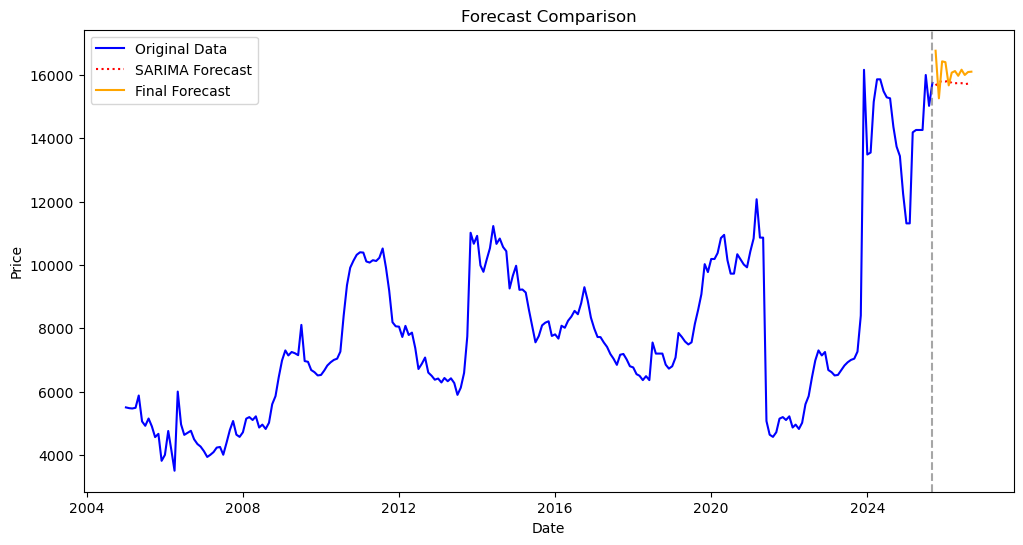

In [105]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming:
# df -> original data (249 months)
# sarima_forecast -> SARIMA forecast (12 months)
# final_forecast -> second model forecast (12 months)

# Make sure indices are datetime for proper alignment
sarima_forecast.index = pd.to_datetime(sarima_forecast.index)
final_forecast.index = pd.to_datetime(final_forecast.index)

plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(df.index, df['price'], label='Original Data', color='blue')

# Plot SARIMA forecast (red dotted)
plt.plot(sarima_forecast.index, sarima_forecast,
         label='SARIMA Forecast', color='red', linestyle='dotted')

# Plot final forecast (orange solid)
plt.plot(final_forecast.index, final_forecast,
         label='Final Forecast', color='orange')

# Optional: draw vertical line where forecast starts
plt.axvline(x=df.index[-1], color='gray', linestyle='--', alpha=0.7)

# Labels and legend
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Forecast Comparison')
plt.legend()

# Save the plot
plt.savefig('result.png', dpi=300, bbox_inches='tight')

plt.show()

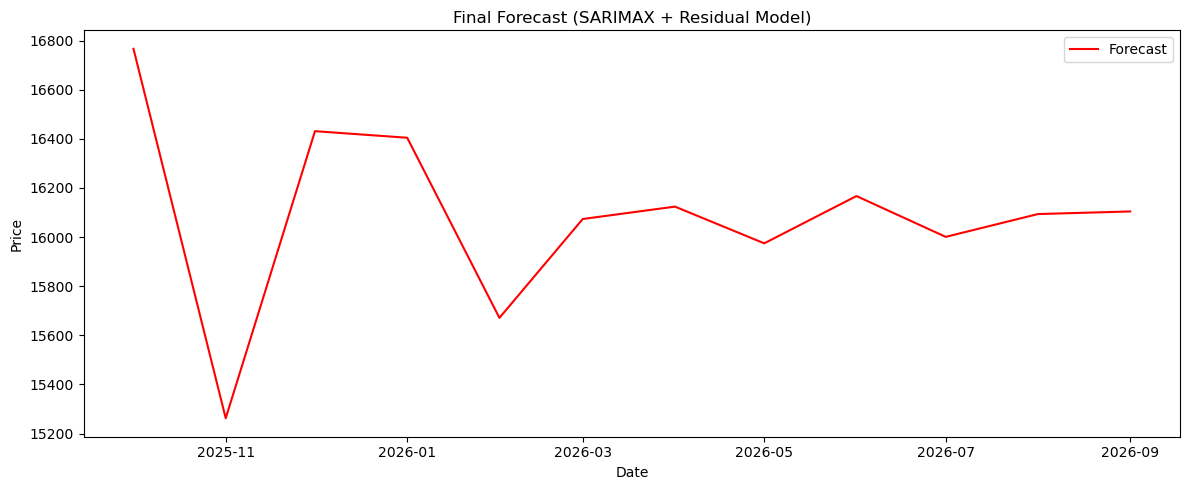

✅ Forecast saved to result.json


In [107]:
import json
import os
import matplotlib.pyplot as plt

# =========================
# ✅ Plot forecast only
# =========================
plt.figure(figsize=(12, 5))

plt.plot(final_forecast.index, final_forecast, label="Forecast", color="red")

plt.title("Final Forecast (SARIMAX + Residual Model)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()

# Save plot
plt.savefig("final_forecast.png", dpi=300, bbox_inches='tight')

plt.show()


# =========================
# ✅ Save forecast to JSON
# =========================

forecast_dict = {
    str(date): float(value)
    for date, value in final_forecast.items()
}

file_path = "result.json"

# Load existing data if file exists
if os.path.exists(file_path):
    with open(file_path, "r") as f:
        try:
            data = json.load(f)
        except:
            data = {}
else:
    data = {}

# Update forecast
data["final_forecast"] = forecast_dict

# Save file
with open(file_path, "w") as f:
    json.dump(data, f, indent=4)

print("✅ Forecast saved to result.json")